1. Import Library

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2. Hubungkan Google Drive

In [37]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. Membaca Dataset dari Google Drive

In [38]:
import os

df = pd.read_csv('/content/drive/MyDrive/Big Data/DATASET/anemia.csv')

df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,15.148357,23.236254,29.838467,83.554121,0
1,0,15.830868,25.217524,27.716110,71.970087,0
2,0,9.323844,21.080395,29.708388,71.446780,1
3,0,15.661515,15.477595,30.851349,87.645449,0
4,1,14.582923,21.016822,27.905567,98.502234,0


4. Informasi Dataset

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


5. Melihat Ukuran Dataset

In [40]:
print("Jumlah Baris dan Kolom :", df.shape)

Jumlah Baris dan Kolom : (1421, 6)


6. Mengecek Missing Value

In [41]:
print(df.isnull().sum())

Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64


7. Mengecek Data Duplikat

In [42]:
print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 0


8. Statistik Deskriptif

In [43]:
df.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.432429,22.922482,30.234469,85.509735,0.441239
std,0.499745,2.031305,4.006752,1.482124,9.640086,0.496710
min,0.000000,6.459035,14.897893,26.553365,68.342872,0.000000
25%,0.000000,11.799681,19.452327,29.043752,77.099197,0.000000
50%,1.000000,13.347842,22.686829,30.279667,85.328351,0.000000
75%,1.000000,15.055625,26.243159,31.446686,94.055096,1.000000
max,1.000000,18.119876,30.738765,34.076028,102.750450,1.000000


9. Menampilkan Tipe Data

In [44]:
print(df.dtypes)

Gender          int64
Hemoglobin    float64
MCH           float64
MCHC          float64
MCV           float64
Result          int64
dtype: object


10. Histogram Semua Variabel

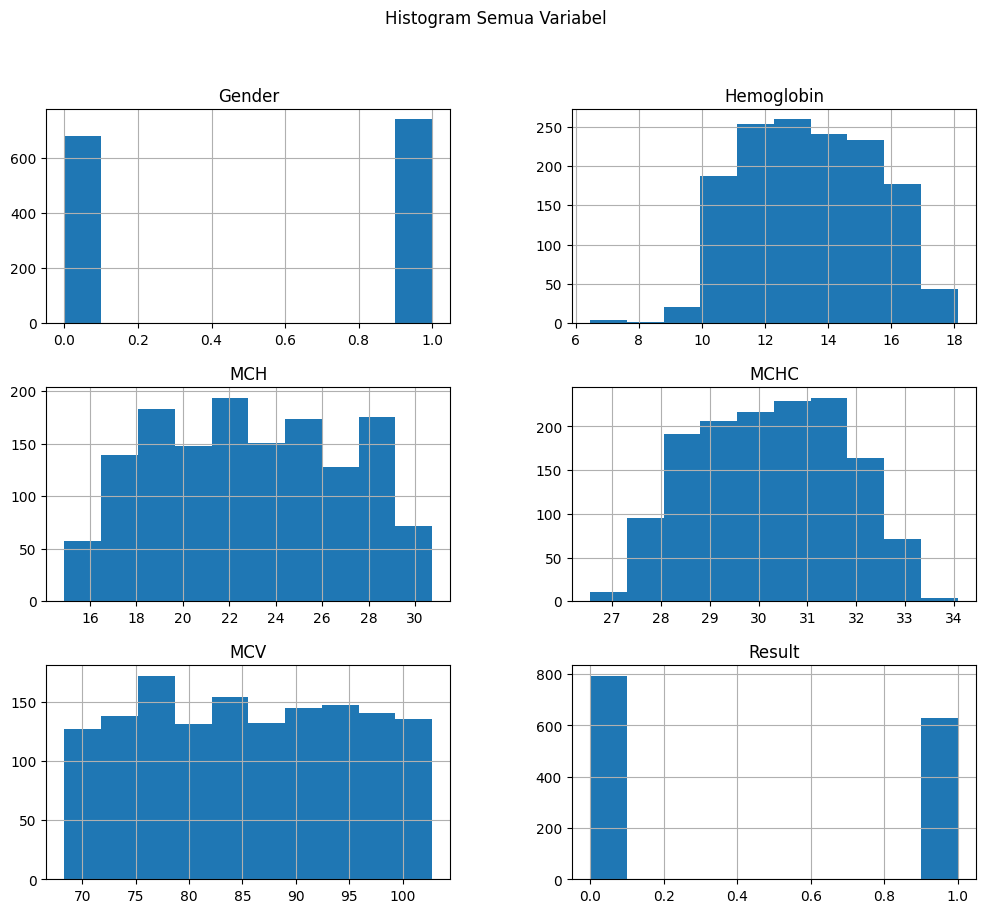

In [45]:
df.hist(figsize=(12,10))

plt.suptitle('Histogram Semua Variabel')

plt.show()

11. Heatmap Korelasi

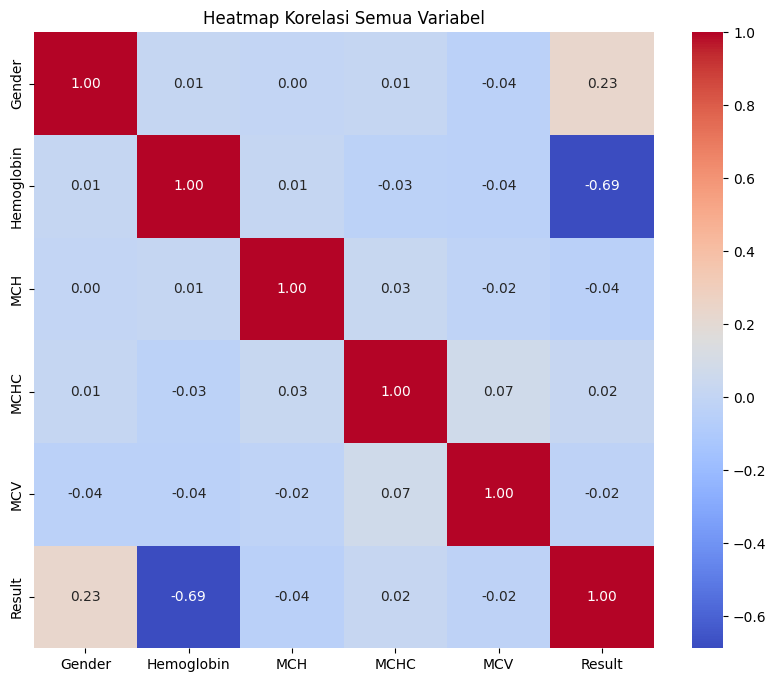

In [46]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Semua Variabel')

plt.show()

12. Menampilkan Korelasi terhadap Hemoglobin

In [47]:
print(df.corr(numeric_only=True)['Hemoglobin'].sort_values(ascending=False))

Hemoglobin    1.000000
Gender        0.014426
MCH           0.012303
MCHC         -0.031676
MCV          -0.039445
Result       -0.687049
Name: Hemoglobin, dtype: float64


13. Scatter Plot

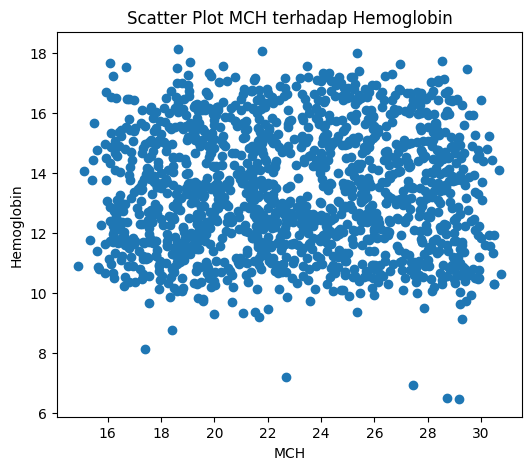

In [48]:
plt.figure(figsize=(6,5))

plt.scatter(df['MCH'], df['Hemoglobin'])

plt.xlabel('MCH')
plt.ylabel('Hemoglobin')

plt.title('Scatter Plot MCH terhadap Hemoglobin')

plt.show()

14. Regplot Regresi Linier

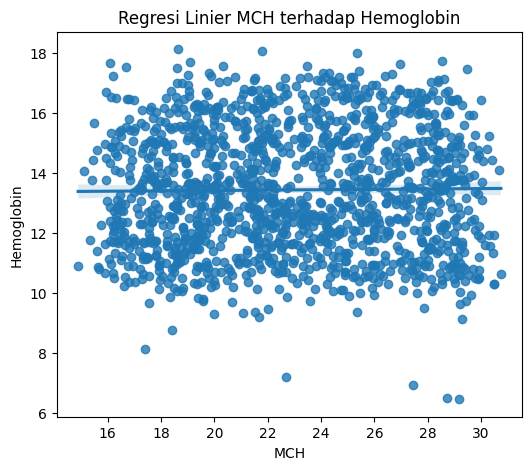

In [49]:
plt.figure(figsize=(6,5))

sns.regplot(
    x='MCH',
    y='Hemoglobin',
    data=df
)

plt.title('Regresi Linier MCH terhadap Hemoglobin')

plt.show()

15. Menentukan Variabel X dan y

In [50]:
X = df[['MCH', 'MCHC', 'MCV']]
y = df['Hemoglobin']

16. Split Data Training dan Testing

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Output Data Training dan testing

In [52]:

print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of y_train: (1136,)
Shape of y_test: (285,)


17. Membuat Model Regresi Linier

In [53]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

18. Menampilkan Koefisien Regresi

In [54]:
print("Koefisien Regresi :")
print(model.coef_)

print("\nIntercept :")
print(model.intercept_)

Koefisien Regresi :
[-0.00601933 -0.05086772 -0.01114757]

Intercept :
16.038948312536654


19. Melakukan Prediksi

In [55]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[13.46558675 13.50710243 13.49139116 13.2356892  13.18687356 13.43813696
 13.31897695 13.35992144 13.53757086 13.41943161]


20. Evaluasi Model Regresi Linier

In [56]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 1.7587445231380068
MSE : 4.187062351347098
RMSE : 2.046231255588453
R2 Score : -0.013110099605556647


21. Membuat Tabel Actual dan Prediction

In [57]:
hasil = pd.DataFrame({
    'Actual': y_test,
    'Prediction': y_pred
})

hasil.head(10)

,Actual,Prediction
51,12.507459,13.465587
289,14.488650,13.507102
677,14.376135,13.491391
1005,16.096743,13.235689
367,9.206296,13.186874
1157,17.726218,13.438137
566,10.380938,13.318977
534,16.074082,13.359921
582,11.816391,13.537571
1375,15.195338,13.419432


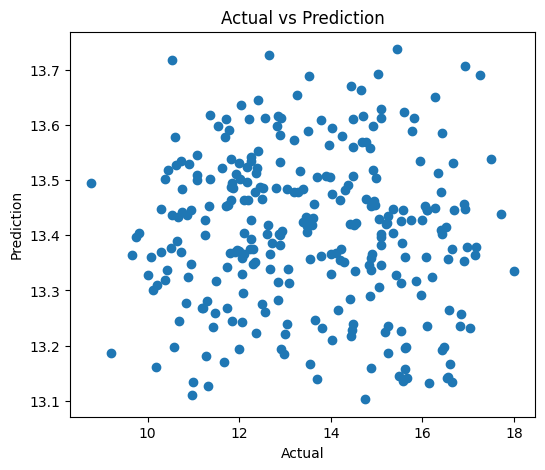

In [58]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual')
plt.ylabel('Prediction')

plt.title('Actual vs Prediction')

plt.show()

22.Line Graph

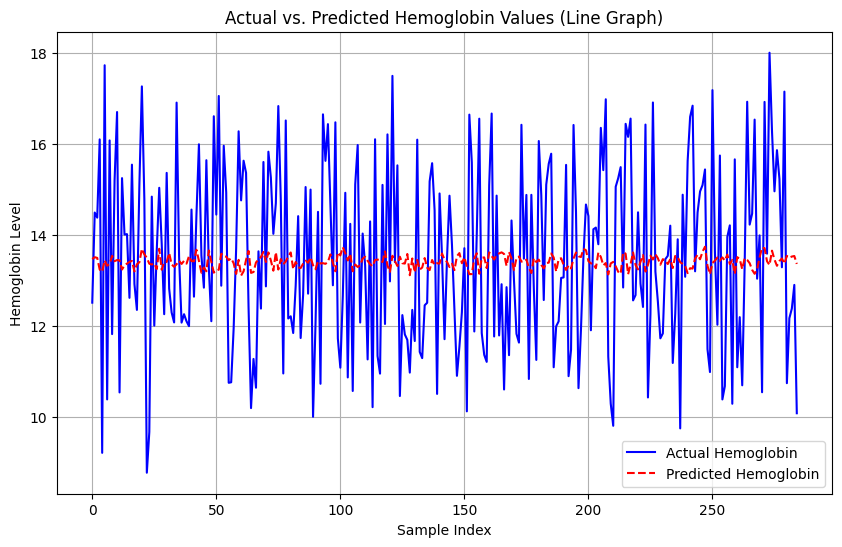

In [59]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual Hemoglobin', color='blue')
plt.plot(y_pred, label='Predicted Hemoglobin', color='red', linestyle='--')

plt.title('Actual vs. Predicted Hemoglobin Values (Line Graph)')
plt.xlabel('Sample Index')
plt.ylabel('Hemoglobin Level')
plt.legend()
plt.grid(True)
plt.show()

## 23. Mencoba Model Lain (e.g., Random Forest Regressor)

In [66]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor Model Trained Successfully.")

Random Forest Regressor Model Trained Successfully.


In [61]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor Model Trained Successfully.")

Random Forest Regressor Model Trained Successfully.


## 24. Melakukan Prediksi dengan Random Forest

In [62]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[13.63706242 13.47074115 13.37277808 12.8011127  14.55910167 14.54505748
 14.42112758 14.52072492 14.44377104 14.26519616]


## 25. Evaluasi Model Random Forest Regressor

In [63]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Evaluation:")
print(f"MAE : {mae_rf}")
print(f"MSE : {mse_rf}")
print(f"RMSE : {rmse_rf}")
print(f"R2 Score : {r2_rf}")

Random Forest Regressor Evaluation:
MAE : 1.6443186799744776
MSE : 3.985811442425931
RMSE : 1.9964497094657634
R2 Score : 0.0355849785360991


## 26. Prediksi Interaktif dengan Model Random Forest

Di bagian ini, Anda dapat mencoba memprediksi kadar Hemoglobin secara interaktif menggunakan model Random Forest yang telah dilatih. Sesuaikan nilai MCH, MCHC, dan MCV di bawah untuk melihat bagaimana kadar Hemoglobin yang diprediksi berubah.

In [64]:
from ipywidgets import interact, FloatSlider
from IPython.display import display
import pandas as pd # Import pandas
from google.colab import drive # Import drive

# Ensure Google Drive is mounted for this cell's execution
drive.mount('/content/drive', force_remount=True)

# Re-load df to ensure it's available in this cell's scope
df = pd.read_csv('/content/drive/MyDrive/Big Data/DATASET/anemia.csv')

# Pre-calculate mean values for the sliders
mch_mean_val = df['MCH'].mean()
mchc_mean_val = df['MCHC'].mean()
mcv_mean_val = df['MCV'].mean()

def predict_interactive(mch, mchc, mcv):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[mch, mchc, mcv]], columns=['MCH', 'MCHC', 'MCV'])

    # Make a prediction using the Random Forest model
    # This assumes rf_model is defined and trained from previous cells.
    predicted_hemoglobin = rf_model.predict(input_data)[0]

    print(f"Prediksi Kadar Hemoglobin: {predicted_hemoglobin:.3f}")

print("Atur slider di bawah untuk mendapatkan prediksi Hemoglobin:")

# Define the sliders with ranges based on dataset statistics
interact(
    predict_interactive,
    mch=FloatSlider(min=14.8, max=30.8, step=0.1, value=mch_mean_val, description='MCH:'),
    mchc=FloatSlider(min=26.5, max=34.1, step=0.1, value=mchc_mean_val, description='MCHC:'),
    mcv=FloatSlider(min=68.3, max=102.8, step=0.1, value=mcv_mean_val, description='MCV:')
);

Mounted at /content/drive
Atur slider di bawah untuk mendapatkan prediksi Hemoglobin:


interactive(children=(FloatSlider(value=22.922481627845976, description='MCH:', max=30.8, min=14.8), FloatSlid…

In [81]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [82]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>